<a href="https://colab.research.google.com/github/Zerberuz/Reconocimiento_de_placas/blob/main/Reconocimiento_de_placas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================== INSTALACIÓN ==================
!apt install tesseract-ocr -qq
!pip install pytesseract -qq

import cv2
import numpy as np
import pytesseract
from google.colab import files
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import csv
from datetime import datetime
import io
import os
import re

# ================== FUNCIONES ==================

def validar_formato_placa(texto):
    if len(texto) != 6:
        return False
    if not texto[:3].isalpha():
        return False
    if not texto[3:].isdigit():
        return False
    return True

def limpiar_texto_placa(texto):
    texto = texto.upper().strip()
    texto = re.sub(r'[^A-Z0-9]', '', texto)
    if len(texto) < 6:
        return ""
    parte_letras = texto[:3]
    parte_numeros = texto[3:6]
    correcciones_letras = {'0': 'O', '1': 'I', '5': 'S', '8': 'B', '6': 'G', '3': 'B'}
    letras_corregidas = ""
    for char in parte_letras:
        if char.isdigit() and char in correcciones_letras:
            letras_corregidas += correcciones_letras[char]
        elif char.isalpha():
            letras_corregidas += char
    correcciones_numeros = {
        'O': '0', 'Q': '0', 'D': '0',
        'I': '1', 'L': '1', 'T': '1',
        'Z': '2', 'S': '5', 'G': '6', 'B': '8'
    }
    numeros_corregidos = ""
    for char in parte_numeros:
        if char.isalpha() and char in correcciones_numeros:
            numeros_corregidos += correcciones_numeros[char]
        elif char.isdigit():
            numeros_corregidos += char
    if len(letras_corregidas) >= 3 and len(numeros_corregidos) >= 3:
        placa_final = letras_corregidas[:3] + numeros_corregidos[:3]
        if validar_formato_placa(placa_final):
            return placa_final
    return ""

def preprocesar_imagen_placa(plate_img):
    if len(plate_img.shape) == 3:
        plate_img = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    if plate_img.shape[0] < 100:
        scale = 100 / plate_img.shape[0]
        plate_img = cv2.resize(plate_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    plate_img = cv2.fastNlMeansDenoising(plate_img, h=10)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    plate_img = clahe.apply(plate_img)
    _, plate_thresh = cv2.threshold(plate_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(plate_thresh) < 127:
        plate_thresh = cv2.bitwise_not(plate_thresh)
    return plate_thresh

def extraer_texto_con_ocr(plate_img):
    resultados = []
    plate_proc = preprocesar_imagen_placa(plate_img)
    configs = [r'--oem 3 --psm 7', r'--oem 3 --psm 8', r'--oem 3 --psm 13']
    for config in configs:
        try:
            texto = pytesseract.image_to_string(plate_proc, config=config)
            texto_limpio = limpiar_texto_placa(texto)
            if texto_limpio:
                resultados.append(texto_limpio)
            plate_inv = cv2.bitwise_not(plate_proc)
            texto_inv = pytesseract.image_to_string(plate_inv, config=config)
            texto_inv_limpio = limpiar_texto_placa(texto_inv)
            if texto_inv_limpio:
                resultados.append(texto_inv_limpio)
        except:
            continue
    if resultados:
        from collections import Counter
        contador = Counter(resultados)
        return contador.most_common(1)[0][0]
    return ""

def detectar_placa_por_color(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_yellow1 = np.array([10, 50, 50])
    upper_yellow1 = np.array([40, 255, 255])
    lower_yellow2 = np.array([15, 80, 80])
    upper_yellow2 = np.array([35, 255, 255])
    mask1 = cv2.inRange(hsv, lower_yellow1, upper_yellow1)
    mask2 = cv2.inRange(hsv, lower_yellow2, upper_yellow2)
    mask = cv2.bitwise_or(mask1, mask2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(contour)
        if (2.0 < aspect_ratio < 5.0 and area > 1500 and w > 100 and h > 30):
            candidatos.append((contour, x, y, w, h, area))
    return sorted(candidatos, key=lambda x: x[5], reverse=True)

def detectar_placa_por_bordes(img, gray):
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 200)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.dilate(edges, kernel, iterations=1)
    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:30]
    candidatos = []
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
        if len(approx) >= 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)
            area = cv2.contourArea(contour)
            if (2.0 < aspect_ratio < 5.0 and area > 1000 and w > 80 and h > 25):
                candidatos.append((approx, x, y, w, h, area))
    return candidatos

def procesar_imagen_placa(img, nombre_archivo="imagen"):
    img_resultado = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img.copy()
    candidatos_color = detectar_placa_por_color(img)
    candidatos_bordes = detectar_placa_por_bordes(img, gray)
    todos_candidatos = candidatos_color + candidatos_bordes
    candidatos_unicos = []
    for candidato in todos_candidatos:
        _, x, y, w, h, area = candidato
        es_duplicado = False
        for _, x2, y2, w2, h2, _ in candidatos_unicos:
            if (abs(x - x2) < 20 and abs(y - y2) < 20 and abs(w - w2) < 20 and abs(h - h2) < 20):
                es_duplicado = True
                break
        if not es_duplicado:
            candidatos_unicos.append(candidato)
    candidatos_unicos.sort(key=lambda x: x[5], reverse=True)
    mejor_texto = ""
    mejor_contorno = None
    mejor_coords = None
    for i, (contour, x, y, w, h, area) in enumerate(candidatos_unicos[:10]):
        plate_roi = img[y:y+h, x:x+w]
        if plate_roi.size == 0:
            continue
        texto = extraer_texto_con_ocr(plate_roi)
        if validar_formato_placa(texto):
            mejor_texto = texto
            mejor_contorno = contour
            mejor_coords = (x, y, w, h)
            break
    if mejor_texto and mejor_contorno is not None:
        cv2.drawContours(img_resultado, [mejor_contorno], -1, (0, 255, 0), 3)
        x, y, w, h = mejor_coords
        cv2.rectangle(img_resultado, (x, y-40), (x+w, y), (0, 255, 0), -1)
        cv2.putText(img_resultado, mejor_texto, (x+5, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)
    return img_resultado, mejor_texto

placas_detectadas = []

def guardar_placa(placa, nombre_archivo):
    now = datetime.now()
    placas_detectadas.append({
        'fecha': now.strftime("%Y-%m-%d"),
        'hora': now.strftime("%H:%M:%S"),
        'placa': placa,
        'archivo': nombre_archivo
    })

def sistema_reconocimiento_placas():
    continuar = True
    contador_imagen = 1
    while continuar:
        try:
            uploaded = files.upload()
        except:
            break
        if not uploaded:
            break
        for filename, data in uploaded.items():
            nparr = np.frombuffer(data, np.uint8)
            img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
            if img is None:
                continue
            img_procesada, texto_placa = procesar_imagen_placa(img, filename)
            plt.figure(figsize=(12, 6))
            plt.imshow(cv2.cvtColor(img_procesada, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            if texto_placa:
                plt.title(f'PLACA DETECTADA: {texto_placa}', fontsize=16, color='green')
                guardar_placa(texto_placa, filename)
            else:
                plt.title('NO SE DETECTÓ PLACA', fontsize=16, color='red')
            plt.show()
            contador_imagen += 1
        try:
            respuesta = input("¿Procesar otra imagen? (s/n): ").strip().lower()
            if respuesta not in ['s', 'si', 'sí', 'yes', 'y']:
                continuar = False
        except:
            continuar = False
    if placas_detectadas:
        print("Placas detectadas:")
        for i, registro in enumerate(placas_detectadas, 1):
            print(f"{i}. {registro['placa']} - {registro['archivo']} {registro['fecha']} {registro['hora']}")

def generar_csv():
    if not placas_detectadas:
        print("No hay placas registradas")
        return
    output = io.StringIO()
    writer = csv.writer(output)
    writer.writerow(['Fecha', 'Hora', 'Placa', 'Archivo'])
    for registro in placas_detectadas:
        writer.writerow([registro['fecha'], registro['hora'], registro['placa'], registro['archivo']])
    csv_content = output.getvalue()
    with open('placas_registradas.csv', 'w', encoding='utf-8') as f:
        f.write(csv_content)
    files.download('placas_registradas.csv')

def procesar_imagen_individual():
    uploaded = files.upload()
    if not uploaded:
        return
    filename = list(uploaded.keys())[0]
    data = uploaded[filename]
    nparr = np.frombuffer(data, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    img_procesada, texto_placa = procesar_imagen_placa(img, filename)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(img_procesada, cv2.COLOR_BGR2RGB))
    if texto_placa:
        axes[1].set_title(f'Detectada: {texto_placa}', color='green')
        guardar_placa(texto_placa, filename)
    else:
        axes[1].set_title('No detectada', color='red')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

print("Sistema de reconocimiento de placas listo para usar")

tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Sistema de reconocimiento de placas listo para usar


Saving taxi.jpg to taxi (4).jpg


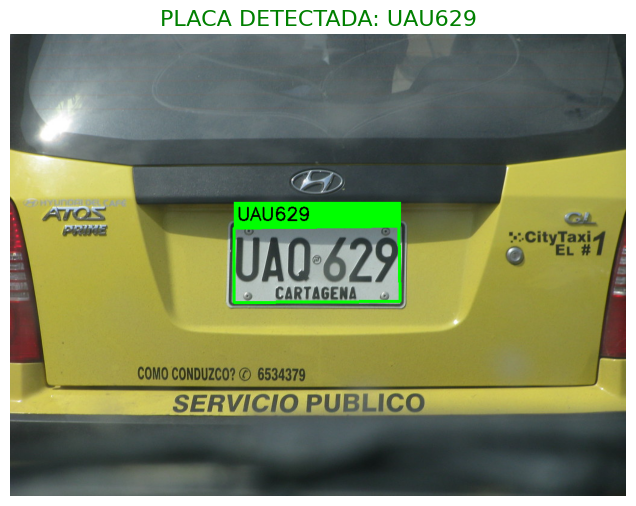

¿Procesar otra imagen? (s/n): s


Saving moto1.png to moto1 (3).png


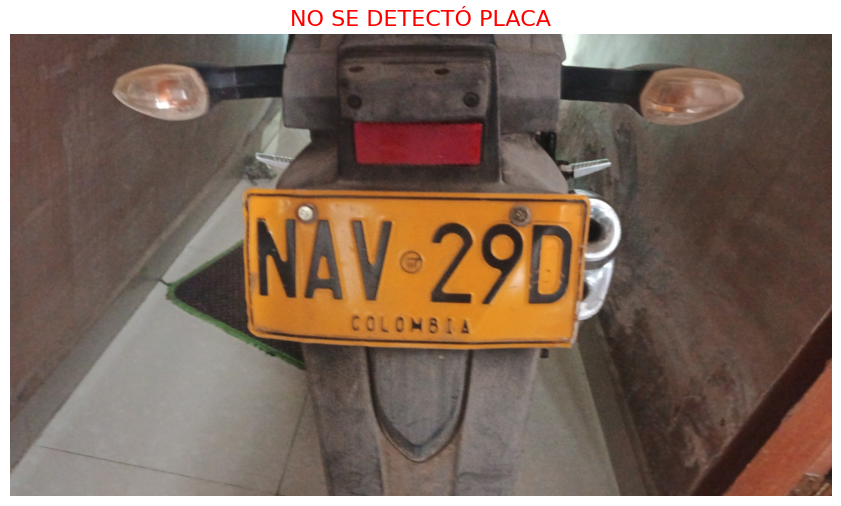

¿Procesar otra imagen? (s/n): n
Placas detectadas:
1. UAU629 - taxi (4).jpg 2025-11-11 18:55:18


In [ ]:
sistema_reconocimiento_placas()

In [ ]:
sistema_reconocimiento_placas()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>